# NLP Knowledge Graph — Exploration & Standardisation

This notebook loads the NLP-extracted KG from 1.2 M PubMed abstracts, explores
its structure, and exports it in the **unified KG schema** required for merging
with the MeSH and Cognitive Atlas graphs.

### Unified KG schema

**Nodes** (`nlp_kg_nodes.parquet`)
| column | dtype | description |
|---|---|---|
| `node_id` | str | canonical identifier (= term for NLP source) |
| `name` | str | human-readable name |
| `node_type` | str | semantic category (anatomical_region, cognitive_construct, …) |
| `source` | str | `"nlp"` |

**Edges** (`nlp_kg_edges.parquet`)
| column | dtype | description |
|---|---|---|
| `subject_id` | str | source node_id |
| `relation_type` | str | `"co_occurs_with"` for all NLP edges |
| `object_id` | str | target node_id |
| `source` | str | `"nlp"` |
| `weight` | float | co-occurrence count |

Raw files live in `data/nlp_neuro_graph_unfiltered/`:
```
kg_nodes_clean.parquet   — term, degree, strength, pagerank, community, alias_count
kg_nodes_typed.parquet   — above + node_label, label_confidence, label_score__*
kg_edges_clean.parquet   — src, dst, weight  (11 M edges)
```

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths are relative to experiments/
BASE = Path("data/nlp_neuro_graph_unfiltered")
OUT  = Path("data/nlp_kg")
OUT.mkdir(parents=True, exist_ok=True)

## Load raw files

In [2]:
nodes_typed = pd.read_parquet(BASE / "kg_nodes_typed.parquet")
edges_raw   = pd.read_parquet(BASE / "kg_edges_clean.parquet")

print(f"Nodes (typed): {len(nodes_typed):,}")
print(f"Edges:         {len(edges_raw):,}")
print()
print(nodes_typed.columns.tolist())
nodes_typed.head(3)

Nodes (typed): 133,625
Edges:         11,043,916

['term', 'degree', 'strength', 'pagerank', 'community', 'alias_count', 'node_label', 'label_confidence', 'label_score__network', 'label_score__anatomical_region', 'label_score__cognitive_construct', 'label_score__method', 'label_score__modality', 'label_score__metric', 'label_score__disorder', 'label_score__intervention', 'label_score__other']


,term,degree,strength,pagerank,community,alias_count,node_label,label_confidence,label_score__network,label_score__anatomical_region,label_score__cognitive_construct,label_score__method,label_score__modality,label_score__metric,label_score__disorder,label_score__intervention,label_score__other
0,a-c,12,885,8.632272e-07,1084,1,other,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,a-d,9,611,8.183174e-07,1084,1,other,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,a-e,4,213,7.445743e-07,1084,1,other,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [3]:
edges_raw.head(3)

,src,dst,weight
0,radiolabeled,radiometal,52.0
1,enables,neuroimaging data,77.0
2,age,feet,306.0


## Explore node distributions

Graph-theoretic metrics:
- **community** — Louvain cluster ID; IDs are arbitrary integers, **not** ordered by size or quality — we filter on community *size* (member count), not ID value
- **degree** — number of unique co-occurring neighbours
- **strength** — sum of edge weights (total co-occurrence volume)
- **alias_count** — how many surface forms map to this term

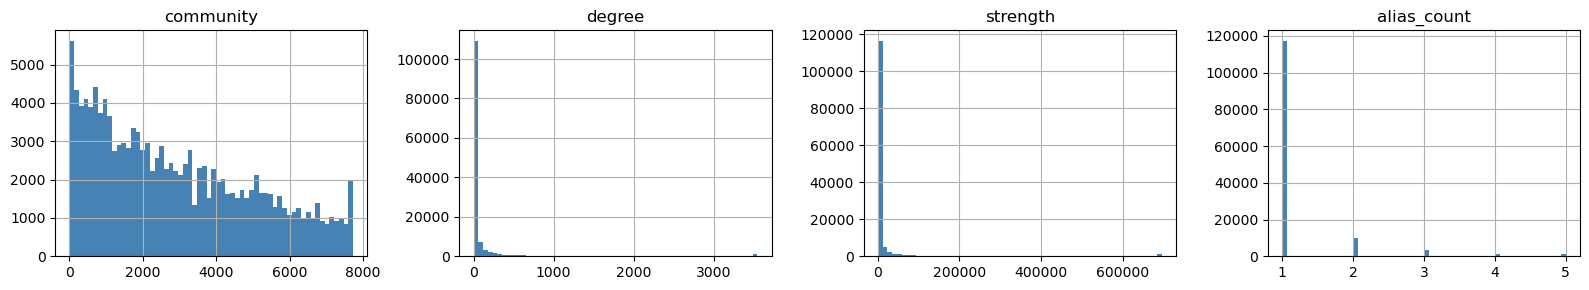

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, col in zip(axes, ["community", "degree", "strength", "alias_count"]):
    nodes_typed[col].clip(upper=nodes_typed[col].quantile(0.99)).hist(
        bins=60, ax=ax, color="steelblue", edgecolor="none"
    )
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [5]:
nodes_typed["node_label"].value_counts()

node_label
other                  88279
modality               16561
method                  7420
anatomical_region       6578
metric                  4836
disorder                4376
intervention            2511
cognitive_construct     2336
network                  728
Name: count, dtype: int64

In [6]:
# Pre-filter label counts — baseline for computing per-type retention rates below
pre_filter_counts = nodes_typed["node_label"].value_counts().rename("pre_filter")
pre_filter_counts

node_label
other                  88279
modality               16561
method                  7420
anatomical_region       6578
metric                  4836
disorder                4376
intervention            2511
cognitive_construct     2336
network                  728
Name: pre_filter, dtype: int64

### Why `other` nodes are excluded

Node types were assigned by a multi-class NLP classifier that outputs a score for each of the 8 semantic categories.  
**`other` is not a "confidence too low" bucket** — every `other` node has `label_confidence = 1.0` and all runner-up category scores are `0.0`.  
The classifier is maximally certain these terms have no recognized neuroscience semantic type.

Top `other` terms by co-occurrence degree are generic vocabulary:  
`data`, `findings`, `patient`, `age`, `images`, `model`, `regions`, `healthy`, `lesions`, …

Contrast with the MeSH KG, where all 31 K descriptors are kept because every MeSH term has a tree-number (inherent semantic type). The co-occurrence notebook there requires only one neuro endpoint per edge — that approach works because non-neuro MeSH nodes still have a type. NLP `other` nodes have no type at all and are therefore useless to the R-GCN's relation typing, so they are dropped at the node level rather than the edge level.

In [7]:
# Verify the 'other' classification is not uncertainty — confirm all scores are hard.
other_nodes = nodes_typed[nodes_typed["node_label"] == "other"]
label_score_cols = [c for c in nodes_typed.columns if c.startswith("label_score__") and c != "label_score__other"]

print(f"other nodes: {len(other_nodes):,}")
print(f"All label_confidence == 1.0 : {(other_nodes['label_confidence'] == 1.0).all()}")
print(f"All runner-up scores == 0.0 : {(other_nodes[label_score_cols].max(axis=1) == 0.0).all()}")
print()
print("Top 20 'other' terms by degree (these are what get excluded):")
print(
    other_nodes.nlargest(20, "degree")[["term", "degree"]]
    .to_string(index=False)
)

other nodes: 88,279
All label_confidence == 1.0 : True
All runner-up scores == 0.0 : True

Top 20 'other' terms by degree (these are what get excluded):
               term  degree
               data   52686
           findings   50304
            patient   47647
                age   37173
           revealed   36787
         tomography   33405
             images   29486
              model   28982
            regions   28865
            healthy   28474
        differences   27438
            lesions   26945
         diagnostic   26923
               risk   26358
        performance   25536
          follow-up   25377
             normal   25353
         assessment   24834
computed tomography   24710
           year-old   23643


## Filter nodes

Remove:
- **Small communities** (community size < 20 members) — Louvain IDs are arbitrary integers; we filter on member count, not ID value
- **Hub non-terms** (degree > 10 000 or strength > 2.5 M) — generic words like *study*, *develop*
- **Rare nodes** (degree ≤ 10) — too few connections to be reliable; `strength` lower bound removed as it is redundant with degree and too aggressive for specific low-weight terms
- **Highly ambiguous surface forms** (alias_count ≥ 10) — inspect `dropped_by_alias` cell below before hardening this threshold; high alias counts sometimes indicate important concepts (*hippocampus*, *CA1*, *cornu ammonis*…)
- **`other`-labeled nodes** — no meaningful semantic category assigned

Tune the thresholds here; add terms to `FORCE_INCLUDE` / `FORCE_EXCLUDE` lists.

In [8]:
FORCE_INCLUDE: set[str] = set()  # terms to always keep regardless of thresholds
FORCE_EXCLUDE: set[str] = set()  # terms to always drop

# Filter on community SIZE (number of members), not community ID.
# IDs from Louvain are arbitrary — community 3 is not inherently "fringe" vs. community 500.
community_sizes = nodes_typed["community"].value_counts()
valid_communities = community_sizes[community_sizes >= 20].index

# Type-conditional alias_count limits.
# For anatomical regions / constructs / networks, high alias count signals IMPORTANCE:
#   white matter → WM, white matter tracts, cerebral white matter, …
# For methods / metrics / modalities, many aliases more often means the term should
# collapse to a canonical form (mri scans, mri data, mri findings → mri) — be stricter.
ALIAS_LIMIT = nodes_typed["node_label"].map({
    "anatomical_region":    50,
    "cognitive_construct":  50,
    "network":              50,
    "disorder":             30,
    "modality":             20,
    "method":               15,
    "metric":               15,
    "intervention":         15,
}).fillna(10)  # fallback for any unlisted labels

mask = (
    nodes_typed["community"].isin(valid_communities) &
    (nodes_typed["degree"]   > 10) &
    (nodes_typed["degree"]   < 10_000) &
    (nodes_typed["strength"] < 2_500_000) &
    (nodes_typed["alias_count"] < ALIAS_LIMIT) &
    (nodes_typed["node_label"] != "other")
)

nodes_filtered = nodes_typed[mask | nodes_typed["term"].isin(FORCE_INCLUDE)].copy()
nodes_filtered = nodes_filtered[~nodes_filtered["term"].isin(FORCE_EXCLUDE)]

print(f"Before filter : {len(nodes_typed):>7,}")
print(f"After filter  : {len(nodes_filtered):>7,}")
nodes_filtered["node_label"].value_counts()

Before filter : 133,625
After filter  :  12,841


node_label
modality               4759
method                 1833
anatomical_region      1783
metric                 1470
disorder               1397
cognitive_construct     708
intervention            677
network                 214
Name: count, dtype: int64

In [9]:
# Inspect terms still dropped by the type-conditional alias_count filter.
# Before each run, scan this list — important terms should either go into FORCE_INCLUDE
# or have their per-type limit raised above.
dropped_by_alias = (
    nodes_typed[
        (nodes_typed["alias_count"] >= ALIAS_LIMIT) &
        (nodes_typed["node_label"] != "other")
    ]
    [["term", "node_label", "alias_count", "degree"]]
    .sort_values("alias_count", ascending=False)
)
print(f"Terms dropped by alias_count filter: {len(dropped_by_alias)}")
dropped_by_alias.head(30)

Terms dropped by alias_count filter: 1


,term,node_label,alias_count,degree
46175,functional connectivity,metric,17,16790


In [10]:
# Per-type retention rate — verify that cognitive_construct isn't disproportionately cut.
# Low retention for a semantically important type signals the thresholds need tuning.
post_filter_counts = nodes_filtered["node_label"].value_counts().rename("post_filter")
retention = (
    pd.concat([pre_filter_counts, post_filter_counts], axis=1)
    .drop(index="other", errors="ignore")
    .fillna(0)
    .astype(int)
)
retention["retention_%"] = (retention["post_filter"] / retention["pre_filter"] * 100).round(1)
retention.sort_values("retention_%")

,pre_filter,post_filter,retention_%
node_label,,,
method,7420,1833,24.7
intervention,2511,677,27.0
anatomical_region,6578,1783,27.1
modality,16561,4759,28.7
network,728,214,29.4
cognitive_construct,2336,708,30.3
metric,4836,1470,30.4
disorder,4376,1397,31.9


In [11]:
import re

# Spot-check anatomical_region — the most safety-critical category because the
# brain-region allowlist for constrained decoding is built from it.
# Some terms are miscategorised (clinical outcomes, study design terms).
# Fix obvious errors in FORCE_EXCLUDE or by relabelling before the merge step.
ar_nodes = nodes_filtered[nodes_filtered["node_label"] == "anatomical_region"].copy()
print(f"Total anatomical_region nodes: {len(ar_nodes)}")
print()

# Heuristic flags: patterns that suggest non-anatomical terms slipped through
_suspicious = r"response|outcome|risk factor|controls?|patient|activity|function|behavio[u]?r|performance|finding|result|measure|score"
ar_suspicious = ar_nodes[ar_nodes["term"].str.contains(_suspicious, flags=re.IGNORECASE, na=False)]
print(f"Potentially miscategorised ({len(ar_suspicious)} flagged — review manually):")
ar_suspicious[["term", "label_confidence", "degree"]].sort_values("degree", ascending=False).head(40)

Total anatomical_region nodes: 1783

Potentially miscategorised (214 flagged — review manually):


,term,label_confidence,degree
13442,brain activity,0.500000,8238
22539,complete response,1.000000,2001
13680,brain functional,0.500000,1881
87029,partial response,1.000000,982
12926,bold response,0.500000,754
51083,hemodynamic response,1.000000,727
56088,immune response,1.000000,683
12927,bold responses,0.500000,413
132521,whole-brain functional,0.500000,377
114132,spontaneous brain activity,0.500000,358


## Filter edges

Keep only edges where **both** endpoints are in the filtered node set.

In [12]:
valid_terms = set(nodes_filtered["term"])
edges_filtered = edges_raw[
    edges_raw["src"].isin(valid_terms) &
    edges_raw["dst"].isin(valid_terms)
].copy()

print(f"Edges before filter : {len(edges_raw):>10,}")
print(f"Edges after filter  : {len(edges_filtered):>10,}")
print(f"Weight range        : [{edges_filtered['weight'].min():.0f}, {edges_filtered['weight'].max():.0f}]")

Edges before filter : 11,043,916
Edges after filter  :    155,352
Weight range        : [50, 17708]


In [13]:
# Verify whether the minimum edge weight is intentional or inherited from upstream.
print("Raw edge weight distribution:")
print(edges_raw["weight"].describe().to_string())
print()
min_raw = edges_raw["weight"].min()
if min_raw > 1:
    print(f"NOTE: raw floor is {min_raw:.0f} — set upstream when the raw graph was built, not here.")
    print("      This threshold cannot be lowered in this notebook.")
    print("      Document this for R-GCN tuning: absent weak edges reflect an upstream ≥50 cutoff.")
else:
    print("Raw data starts at 1 — add an explicit minimum weight threshold here.")

Raw edge weight distribution:
count    1.104392e+07
mean     2.089906e+02
std      5.577269e+02
min      5.000000e+01
25%      6.400000e+01
50%      9.400000e+01
75%      1.750000e+02
max      1.183820e+05

NOTE: raw floor is 50 — set upstream when the raw graph was built, not here.
      This threshold cannot be lowered in this notebook.
      Document this for R-GCN tuning: absent weak edges reflect an upstream ≥50 cutoff.


## Sanity checks

Degree distribution should roughly follow a power law (log-log linear).

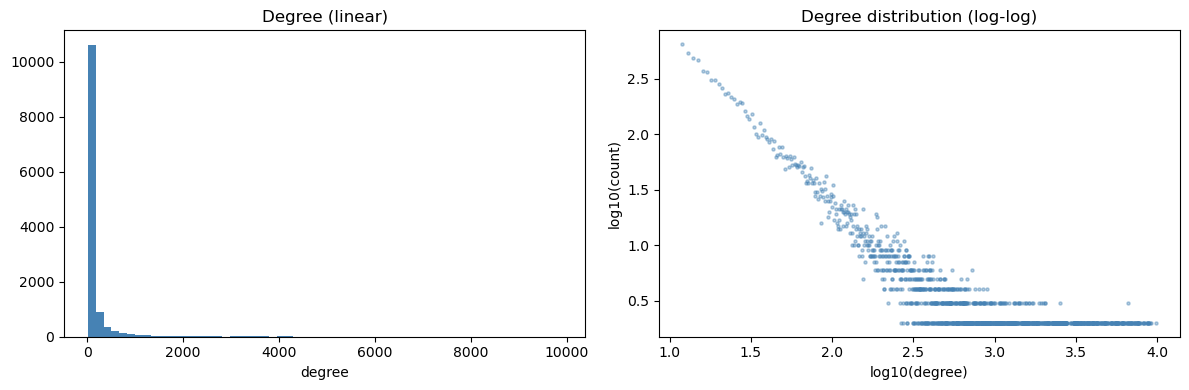

Avg degree : 213.3
Median deg : 35.0


In [14]:
import numpy as np

deg_counts = nodes_filtered["degree"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(nodes_filtered["degree"], bins=60, color="steelblue", edgecolor="none")
axes[0].set_xlabel("degree"); axes[0].set_title("Degree (linear)")

axes[1].scatter(np.log10(deg_counts.index + 1), np.log10(deg_counts.values + 1),
                s=5, alpha=0.4, color="steelblue")
axes[1].set_xlabel("log10(degree)"); axes[1].set_ylabel("log10(count)")
axes[1].set_title("Degree distribution (log-log)")
plt.tight_layout(); plt.show()

print(f"Avg degree : {nodes_filtered['degree'].mean():.1f}")
print(f"Median deg : {nodes_filtered['degree'].median():.1f}")

## Export in unified KG schema

Produces two files consumed by the KG-unification step:
- `data/nlp_kg/nlp_kg_nodes.parquet`
- `data/nlp_kg/nlp_kg_edges.parquet`

In [15]:
# ----- nodes -----
kg_nodes = pd.DataFrame({
    "node_id"   : nodes_filtered["term"],
    "name"      : nodes_filtered["term"],
    "node_type" : nodes_filtered["node_label"],
    "source"    : "nlp",
    # keep graph-metric columns as supplementary information
    "degree"    : nodes_filtered["degree"].values,
    "strength"  : nodes_filtered["strength"].values,
    "pagerank"  : nodes_filtered["pagerank"].values,
    "community" : nodes_filtered["community"].values,
}).reset_index(drop=True)

# ----- edges -----
kg_edges = pd.DataFrame({
    "subject_id"    : edges_filtered["src"].values,
    "relation_type" : "co_occurs_with",
    "object_id"     : edges_filtered["dst"].values,
    "source"        : "nlp",
    "weight"        : edges_filtered["weight"].values,
})

kg_nodes.to_parquet(OUT / "nlp_kg_nodes.parquet", index=False)
kg_edges.to_parquet(OUT / "nlp_kg_edges.parquet", index=False)

print(f"Saved {len(kg_nodes):,} nodes  →  {OUT / 'nlp_kg_nodes.parquet'}")
print(f"Saved {len(kg_edges):,} edges  →  {OUT / 'nlp_kg_edges.parquet'}")
print()
kg_nodes.head(3)

Saved 12,841 nodes  →  data/nlp_kg/nlp_kg_nodes.parquet
Saved 155,352 edges  →  data/nlp_kg/nlp_kg_edges.parquet



,node_id,name,node_type,source,degree,strength,pagerank,community
0,abbreviated mri,abbreviated mri,modality,nlp,36,2924,0.000001,1203
1,abdominal aortic aneurysms,abdominal aortic aneurysms,disorder,nlp,46,5193,0.000002,2784
2,abdominal ct,abdominal ct,modality,nlp,258,29937,0.000006,853


In [16]:
kg_edges.head(3)

,subject_id,relation_type,object_id,source,weight
0,diffusion tensor,co_occurs_with,status scale,nlp,121.0
1,chemoradiotherapy,co_occurs_with,neoadjuvant chemoradiotherapy,nlp,1437.0
2,myocardial perfusion imaging,co_occurs_with,stress myocardial perfusion,nlp,79.0


## Summary

| metric | value |
|---|---|
| Unique nodes | `kg_nodes` |
| Unique edges | `kg_edges` |
| Relation types | `co_occurs_with` |
| Node types | see `value_counts` above |

These files are the NLP input to **Phase 2 — KG Unification**.

In [17]:
print("=== NLP KG Summary ===")
print(f"Nodes : {len(kg_nodes):>8,}")
print(f"Edges : {len(kg_edges):>8,}")
print()
print("Node type breakdown:")
print(kg_nodes["node_type"].value_counts().to_string())

=== NLP KG Summary ===
Nodes :   12,841
Edges :  155,352

Node type breakdown:
node_type
modality               4759
method                 1833
anatomical_region      1783
metric                 1470
disorder               1397
cognitive_construct     708
intervention            677
network                 214
